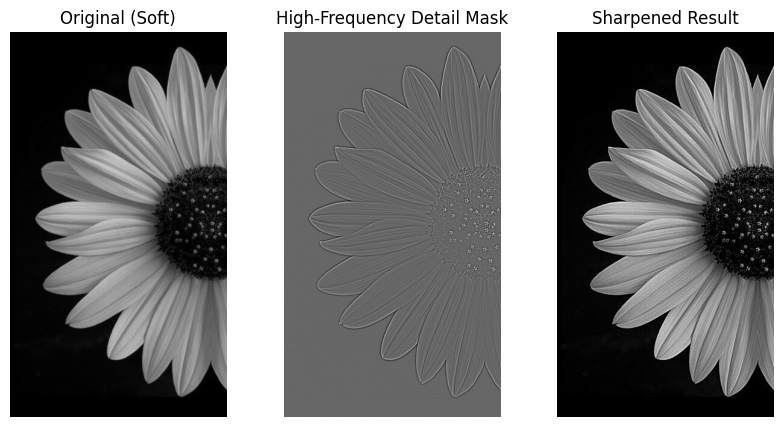

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

im = cv2.imread('images/a1images/sunflower.jpg', cv2.IMREAD_GRAYSCALE)
assert im is not None, 'Image not found'

# Bblurred versio
gaussian_blur = cv2.GaussianBlur(im, (5, 5), 1.5)

# Calculate the Detail Mask
detail_mask = cv2.subtract(im.astype(np.float32), gaussian_blur.astype(np.float32))

# Add the mask back to the original
gain = 1.5
sharpened = cv2.addWeighted(im.astype(np.float32), 1.0, detail_mask, gain, 0)
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original (Soft)')
ax[0].axis('off')

ax[1].imshow(detail_mask, cmap='gray')
ax[1].set_title('High-Frequency Detail Mask')
ax[1].axis('off')

ax[2].imshow(sharpened, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Sharpened Result')
ax[2].axis('off')

plt.show()